# Hamilton experiment: compare methods by sample size N

For each N in N_LIST: naive mean, AR(4) OLS, LSTM, Hamilton filter. MSE table, MSE vs N plot, and Hamilton parameter recovery table.

In [25]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression

In [26]:
SAVED_DIR = Path("saved_data")
N_LIST = [200, 1000, 5000, 25000, 100000]  # subset e.g. [200, 1000, 5000] for quick runs
WINDOW_SIZE = 4
SEQ_LEN = 20
device = torch.device("mps" if getattr(torch, "mps", None) and torch.mps.is_available() else "cpu")

## LSTM model and training helper

In [27]:
class HamiltonLSTM(nn.Module):
    def __init__(self, seq_len, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.unsqueeze(-1)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

In [28]:
def get_xy_arrays(series, window_size):
    dy = series.values.astype(np.float32)
    n = len(dy) - window_size
    X = np.array([dy[i : i + window_size] for i in range(n)])
    Y = dy[window_size:]
    return X, Y

def mse(y_true, y_pred):
    return np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)

def train_lstm_and_mse(dy, split_idx, seq_len, device, epochs=80, batch_size=64, lr=1e-3, disp=False):
    train_dy = dy.iloc[:split_idx]
    val_dy = dy.iloc[split_idx - seq_len :]
    dy_np = dy.values.astype(np.float32)
    n_train = split_idx - seq_len
    X_tr = np.array([dy_np[i : i + seq_len] for i in range(n_train)])
    Y_tr = dy_np[seq_len : split_idx]
    n_val = len(val_dy) - seq_len
    X_val = np.array([val_dy.values.astype(np.float32)[i : i + seq_len] for i in range(n_val)])
    Y_val = val_dy.values.astype(np.float32)[seq_len:]
    train_ds = TensorDataset(torch.tensor(X_tr), torch.tensor(Y_tr))
    val_ds = TensorDataset(torch.tensor(X_val), torch.tensor(Y_val))
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=False)
    model = HamiltonLSTM(seq_len=seq_len, hidden_size=64).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device).unsqueeze(1)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
    model.eval()
    with torch.no_grad():
        xv = torch.tensor(X_val, dtype=torch.float32).to(device)
        pred = model(xv).cpu().numpy().ravel()
    return float(mse(Y_val, pred))

## Run all methods for each N

In [29]:
results_rows = []
hamilton_params_by_N = {}

for N in N_LIST:
    path = SAVED_DIR / f"gnp_N{N}.csv"
    if not path.exists():
        print(f"Skip N={N}: {path} not found. Run data_generating_process.ipynb first.")
        continue
    df = pd.read_csv(path)
    dy = df["dy"].astype(np.float64)
    split_idx = int(len(dy) * 0.8)
    if split_idx < WINDOW_SIZE + 10 or len(dy) - split_idx < 5:
        print(f"Skip N={N}: too short for split.")
        continue

    train_dy = dy.iloc[:split_idx]
    val_dy_ols = dy.iloc[split_idx - WINDOW_SIZE :]
    X_train, Y_train = get_xy_arrays(train_dy, WINDOW_SIZE)
    X_val_ols, Y_val_ols = get_xy_arrays(val_dy_ols, WINDOW_SIZE)

    mean_pred = np.mean(Y_train)
    mse_naive = mse(Y_val_ols, np.full_like(Y_val_ols, mean_pred))

    ols = LinearRegression().fit(X_train, Y_train)
    mse_ols = mse(Y_val_ols, ols.predict(X_val_ols))

    epochs = 60 if N < 2000 else 80
    mse_lstm = train_lstm_and_mse(dy, split_idx, SEQ_LEN, device, epochs=epochs, disp=False)

    try:
        # Fit on full series (statsmodels predict(start, end) raises NotImplementedError for subset)
        mod = MarkovAutoregression(dy, k_regimes=2, order=4, trend="n", switching_ar=False)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            res = mod.fit(em_iter=100, maxiter=200, disp=False, search_reps=20, search_iter=5)
        pred_ham = mod.predict(res.params, probabilities="predicted")
        pred_ham = np.asarray(pred_ham).flatten()[split_idx:]
        Y_val_ham = dy.iloc[split_idx:].values
        mse_hamilton = mse(Y_val_ham, pred_ham)
        hamilton_params_by_N[N] = dict(res.params)
    except Exception as e:
        mse_hamilton = np.nan
        hamilton_params_by_N[N] = {}
        print(f"N={N} Hamilton fit failed: {type(e).__name__}: {e}")

    results_rows.append({
        "N": N,
        "MSE_naive": mse_naive,
        "MSE_ols": mse_ols,
        "MSE_lstm": mse_lstm,
        "MSE_hamilton": mse_hamilton,
    })
    print(f"N={N}: naive={mse_naive:.4f} ols={mse_ols:.4f} lstm={mse_lstm:.4f} hamilton={mse_hamilton:.4f}")

results_df = pd.DataFrame(results_rows)
results_df

N=200 Hamilton fit failed: ValueError: operands could not be broadcast together with shapes (40,) (32,) 
N=200: naive=0.7528 ols=0.5493 lstm=0.6591 hamilton=nan
N=1000 Hamilton fit failed: ValueError: operands could not be broadcast together with shapes (200,) (192,) 
N=1000: naive=0.9215 ols=0.7839 lstm=0.8157 hamilton=nan


KeyboardInterrupt: 

## MSE vs N (log scale)

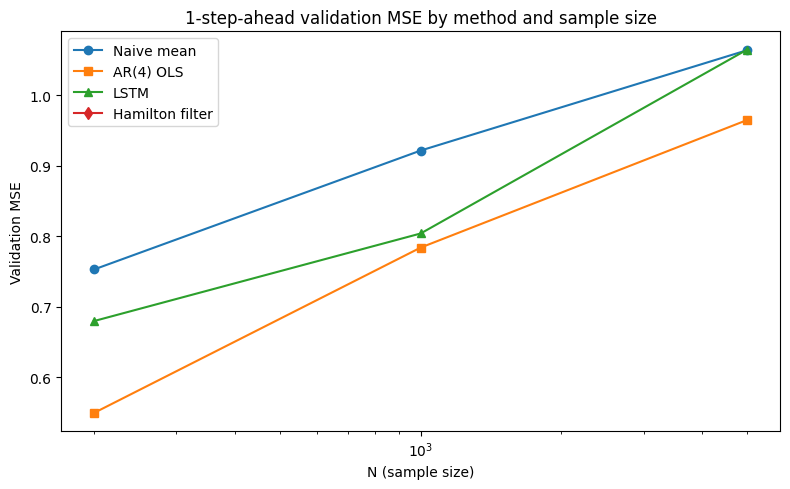

In [ ]:
if len(results_df) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.semilogx(results_df["N"], results_df["MSE_naive"], "o-", label="Naive mean")
    ax.semilogx(results_df["N"], results_df["MSE_ols"], "s-", label="AR(4) OLS")
    ax.semilogx(results_df["N"], results_df["MSE_lstm"], "^-", label="LSTM")
    ax.semilogx(results_df["N"], results_df["MSE_hamilton"], "d-", label="Hamilton filter")
    ax.set_xlabel("N (sample size)")
    ax.set_ylabel("Validation MSE")
    ax.legend()
    ax.set_title("1-step-ahead validation MSE by method and sample size")
    plt.tight_layout()
    plt.show()

## Hamilton parameter recovery (true vs estimated)

In [ ]:
true_path = SAVED_DIR / "true_params.csv"
if not true_path.exists():
    print("Run data_generating_process.ipynb to create true_params.csv.")
else:
    true_params = pd.read_csv(true_path).set_index("param")["value"]
    # Map statsmodels param names to our names (model-dependent; adjust if param_names differ)
    sm_to_ours = {
        "regime 0 mean": "MU0",
        "regime 1 mean": "MU1",
        "ar.L1": "PHI1",
        "ar.L2": "PHI2",
        "ar.L3": "PHI3",
        "ar.L4": "PHI4",
        "sigma2": "SIGMA2",
    }
    # Transition: statsmodels often uses p[0->0], p[1->0] etc.
    rows = []
    for N, est in hamilton_params_by_N.items():
        if not est:
            continue
        row = {"N": N}
        for sm_name, our_name in sm_to_ours.items():
            if sm_name in est:
                val = est[sm_name]
                if our_name == "SIGMA2":
                    true_val = true_params.get("SIGMA", np.nan) ** 2
                else:
                    true_val = true_params.get(our_name, np.nan)
                row[f"{our_name}_est"] = val
                row[f"{our_name}_true"] = true_val
                row[f"{our_name}_err"] = val - true_val if not np.isnan(true_val) else np.nan
        for pname in ["P", "Q"]:
            if pname in true_params.index:
                row[f"{pname}_true"] = true_params[pname]
        rows.append(row)
    if rows:
        recovery_df = pd.DataFrame(rows)
        display(recovery_df)
    else:
        print("No Hamilton fits to show. Param names may differ; check mod.param_names after fit.")

No Hamilton fits to show. Param names may differ; check mod.param_names after fit.


In [ ]:
# Compact table: one row per parameter, true value and estimated value per N (shows convergence)
if true_path.exists() and hamilton_params_by_N:
    true_series = pd.read_csv(true_path).set_index("param")["value"]
    ours_to_sm = {"MU0": "regime 0 mean", "MU1": "regime 1 mean", "PHI1": "ar.L1", "PHI2": "ar.L2", "PHI3": "ar.L3", "PHI4": "ar.L4"}
    params_show = ["MU0", "MU1", "PHI1", "PHI2", "PHI3", "PHI4", "SIGMA"]
    Ns = sorted(hamilton_params_by_N.keys())
    rows = []
    for p in params_show:
        true_val = true_series.get(p, np.nan)
        row = {"param": p, "true": true_val}
        for N in Ns:
            est = hamilton_params_by_N[N]
            if p == "SIGMA":
                v = np.sqrt(est["sigma2"]) if "sigma2" in est else np.nan
            else:
                v = est.get(ours_to_sm.get(p, p), np.nan)
            row[f"N={N}"] = v
        rows.append(row)
    display(pd.DataFrame(rows).set_index("param"))

,true,N=200,N=1000,N=5000
param,,,,
MU0,-0.2132,NaN,NaN,NaN
MU1,1.1283,NaN,NaN,NaN
PHI1,0.0898,NaN,NaN,NaN
PHI2,-0.0186,NaN,NaN,NaN
PHI3,-0.1743,NaN,NaN,NaN
PHI4,-0.0839,NaN,NaN,NaN
SIGMA,0.7962,NaN,NaN,NaN
